## Marketing Campaign Performance Analysis

Step 1: Environment Setup & Data Categorization
Professional analysts ensure data types are correctly defined. Converting "Promotion" and "MarketSize" to Categorical types ensures that statistical models treat them as groups rather than mathematical values.

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import plotly.express as px
from statsmodels.graphics.factorplots import interaction_plot
df = pd.read_csv(r"C:\Users\Renad\Downloads\WA_Marketing-Campaign.csv")

df['Promotion'] = df['Promotion'].astype('category')
df['MarketSize'] = df['MarketSize'].astype('category')


## Step 2: Data Integrity & Quality Check (EDA)

Before analyzing, we verify data cleanliness and ensure the experiment was balanced across all promotion groups.

In [37]:
print(df.isnull().sum())
print(df.describe())

print(df.groupby('Promotion')['LocationID'].count())

MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64
         MarketID  LocationID  AgeOfStore        week  SalesInThousands
count  548.000000  548.000000  548.000000  548.000000        548.000000
mean     5.715328  479.656934    8.503650    2.500000         53.466204
std      2.877001  287.973679    6.638345    1.119055         16.755216
min      1.000000    1.000000    1.000000    1.000000         17.340000
25%      3.000000  216.000000    4.000000    1.750000         42.545000
50%      6.000000  504.000000    7.000000    2.500000         50.200000
75%      8.000000  708.000000   12.000000    3.250000         60.477500
max     10.000000  920.000000   28.000000    4.000000         99.650000
Promotion
1    172
2    188
3    188
Name: LocationID, dtype: int64


## Visualization: Experimental Design Balance
A Bar Plot is added here to visualize the number of test locations assigned to each promotion group, confirming a balanced experimental design.

C:\Users\Renad\AppData\Local\Temp\ipykernel_11896\1054644163.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Promotion', data=df, palette='muted')


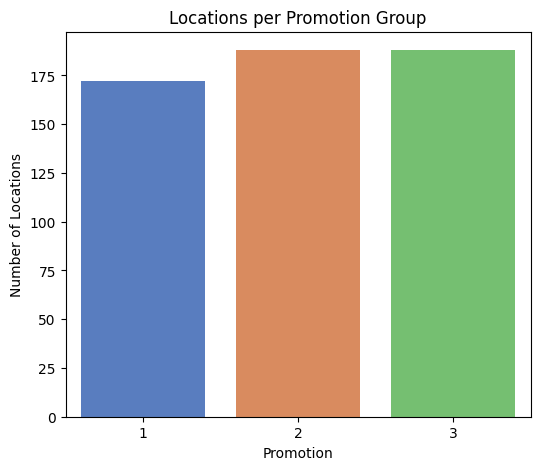

In [46]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Promotion', data=df, palette='muted')
plt.title('Locations per Promotion Group')
plt.ylabel('Number of Locations')
plt.show()

## Step 3: Interactive Data Storytelling

Using Plotly allows recruiters or stakeholders to interact with the data, zoom in on specific stores, and observe how Store Age and Market Size correlate with sales.

In [39]:
fig = px.scatter(df, x="AgeOfStore", y="SalesInThousands", color="Promotion",facet_col="MarketSize",title="Interactive EDA: Sales Drivers by Market & Promotion")
fig.update_traces(marker=dict(size=4, opacity=0.5))
fig.show()

## Step 4: Interaction Analysis (Two-Way ANOVA)

This goes beyond basic averages. We test if a promotion's success depends on the Market Size. This "Interaction Effect" is key for targeted marketing strategies.

In [40]:
model_int = ols('SalesInThousands ~ C(Promotion) * C(MarketSize)', data=df).fit()
anova_table = sm.stats.anova_lm(model_int, typ=2)

print("\n--- Two-Way ANOVA Table (Interaction Analysis) ---")
print(anova_table)


--- Two-Way ANOVA Table (Interaction Analysis) ---
                                  sum_sq     df           F        PR(>F)
C(Promotion)                12979.270759    2.0   56.241683  6.549744e-23
C(MarketSize)               77803.041539    2.0  337.135582  1.087739e-95
C(Promotion):C(MarketSize)   2116.739627    4.0    4.586120  1.194444e-03
Residual                    62194.324249  539.0         NaN           NaN


## Visualization: Interaction Plot
A Plot visualizes the Two-Way ANOVA results, showing whether the lines for each market size are parallel. If not, an interaction exists.

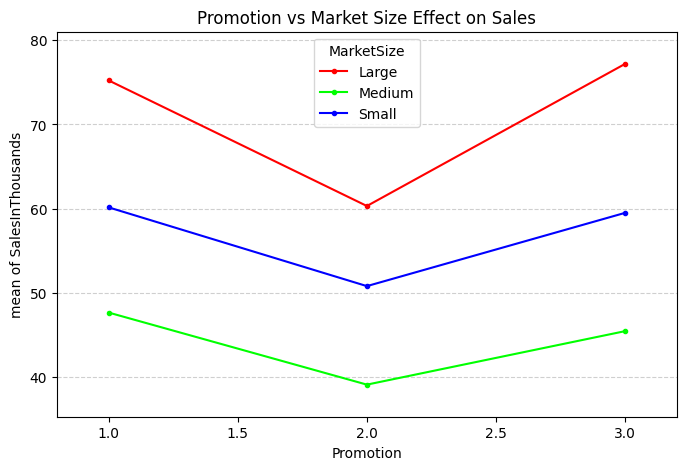

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
interaction_plot(x=df['Promotion'], trace=df['MarketSize'], response=df['SalesInThousands'], ax=ax)
plt.title('Promotion vs Market Size Effect on Sales')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## Step 5: Post-hoc Analysis (Tukey HSD)
Once the ANOVA confirms a significant difference, we use the Tukey HSD test to pinpoint exactly which promotion outperformed the others and by what margin.

In [42]:
tukey = pairwise_tukeyhsd(endog=df['SalesInThousands'], groups=df['Promotion'], alpha=0.05)
print("\n--- Tukey HSD Pairwise Comparison ---")
print(tukey)


--- Tukey HSD Pairwise Comparison ---
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


## Visualization: Sales Distribution Boxplot
While Tukey HSD gives statistical significance, a Boxplot visualizes the distribution, median, and outliers for each promotion, making the results easier to digest for stakeholders.

C:\Users\Renad\AppData\Local\Temp\ipykernel_11896\1352348880.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Promotion', y='SalesInThousands', data=df, palette='Set3')


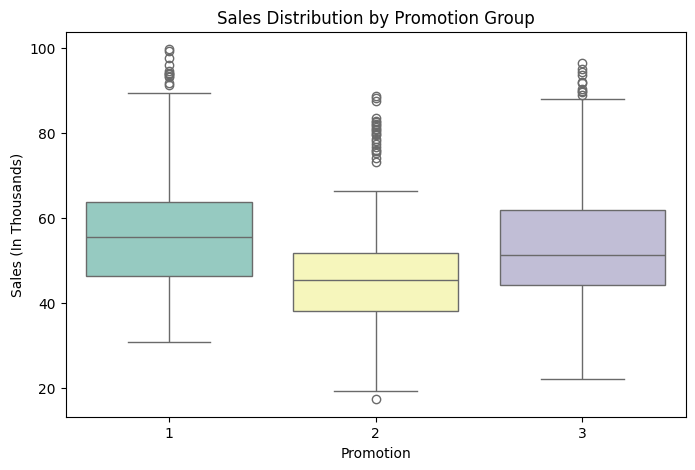

In [43]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Promotion', y='SalesInThousands', data=df, palette='Set3')
plt.title('Sales Distribution by Promotion Group')
plt.ylabel('Sales (In Thousands)')
plt.show()

## Step 6: Predictive Modeling (Multiple Linear Regression)
We build a regression model to quantify the "weight" of each factor. This allows us to predict sales and understand the ROI of each variable.

In [44]:
df_refined = pd.get_dummies(df, columns=['MarketSize', 'Promotion'], drop_first=True)

X = df_refined[['AgeOfStore', 'week', 'MarketSize_Medium', 'MarketSize_Small', 'Promotion_2', 'Promotion_3']]
X = sm.add_constant(X) 
y = df_refined['SalesInThousands']

reg_model = sm.OLS(y, X.astype(float)).fit()
print("\n--- Predictive Model Summary (OLS Regression) ---")
print(reg_model.summary())


--- Predictive Model Summary (OLS Regression) ---
                            OLS Regression Results                            
Dep. Variable:       SalesInThousands   R-squared:                       0.582
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     125.6
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           4.01e-99
Time:                        19:35:04   Log-Likelihood:                -2082.7
No. Observations:                 548   AIC:                             4179.
Df Residuals:                     541   BIC:                             4209.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

## Visualization: Residual Plot
A Residual Plot is added here to check the regression model assumptions. Randomly scattered residuals indicate a reliable model.

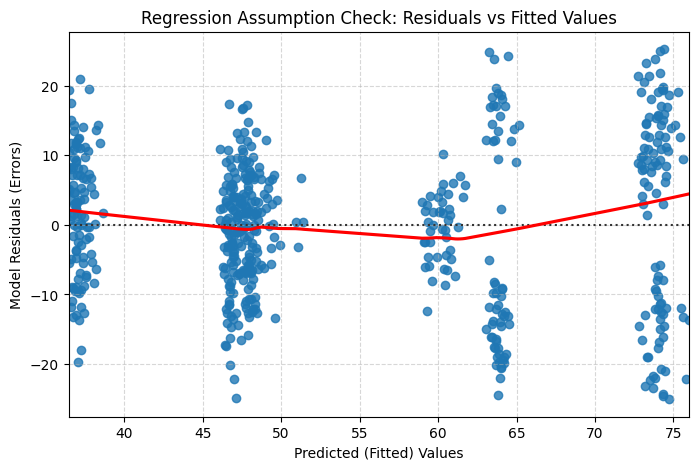

In [45]:
plt.figure(figsize=(8, 5))
sns.residplot(x=reg_model.fittedvalues, y=reg_model.resid, lowess=True, line_kws={'color': 'red'})
plt.title('Regression Assumption Check: Residuals vs Fitted Values')
plt.xlabel('Predicted (Fitted) Values')
plt.ylabel('Model Residuals (Errors)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Strategic Summary for Recruiters:
When presenting this project, emphasize these three points:

Statistical Rigor: I didn't just look at means; I used ANOVA and Tukey HSD to prove significance at a 95% confidence level.

Predictive Power: I built a Regression Model that quantifies the impact of every variable, moving the business from descriptive to predictive analytics.

Actionable Insights: My analysis identified that Promotion 1 is the optimal choice for Large Markets, while Promotion 2 should be discontinued due to statistical underperformance.